In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

In [9]:
df = pd.read_csv("exoplanets.csv", comment = "#")
print("Number of exoplanets:", len(df))
print("Columns in dataset:", df.columns)

Number of exoplanets: 39803
Columns in dataset: Index(['pl_name', 'hostname', 'discoverymethod', 'disc_year', 'disc_facility',
       'disc_telescope', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim',
       'pl_massj', 'pl_massjerr1', 'pl_massjerr2', 'pl_massjlim'],
      dtype='object')


In [10]:
df.head()

,pl_name,hostname,discoverymethod,disc_year,disc_facility,disc_telescope,pl_radj,pl_radjerr1,pl_radjerr2,pl_radjlim,pl_massj,pl_massjerr1,pl_massjerr2,pl_massjlim
0,11 Com b,11 Com,Radial Velocity,2007.0,Xinglong Station,2.16 m Telescope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11 Com b,11 Com,Radial Velocity,2007.0,Xinglong Station,2.16 m Telescope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11 Com b,11 Com,Radial Velocity,2007.0,Xinglong Station,2.16 m Telescope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11 UMi b,11 UMi,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,2.0 m Alfred Jensch Telescope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11 UMi b,11 UMi,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,2.0 m Alfred Jensch Telescope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


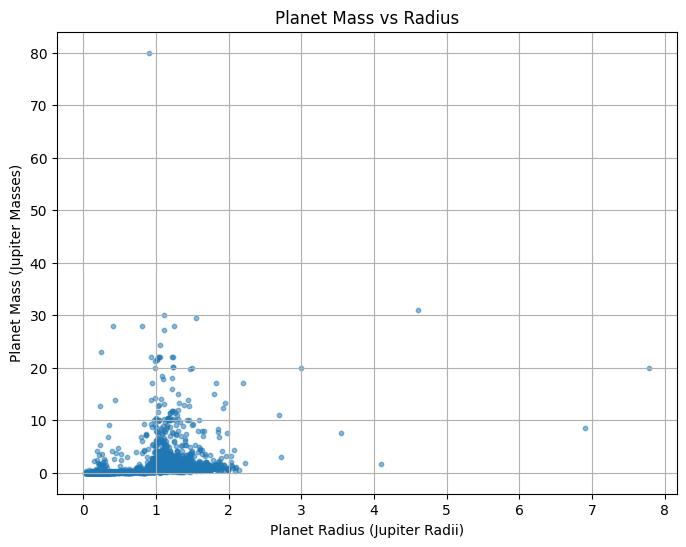

In [74]:
plt.figure(figsize = (8,6))
plt.scatter(df["pl_radj"], df["pl_massj"], s = 10, alpha = 0.5)
plt.xlabel("Planet Radius (Jupiter Radii)")
plt.ylabel("Planet Mass (Jupiter Masses)")
plt.title("Planet Mass vs Radius")
plt.grid(True)
plt.show()

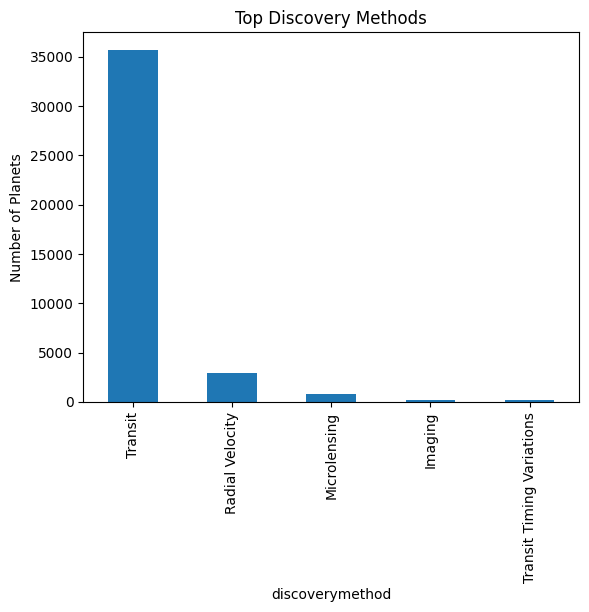

In [86]:
df["discoverymethod"].value_counts().head(5).plot(kind = "bar")
plt.title("Top Discovery Methods")
plt.ylabel("Number of Planets")
plt.show()

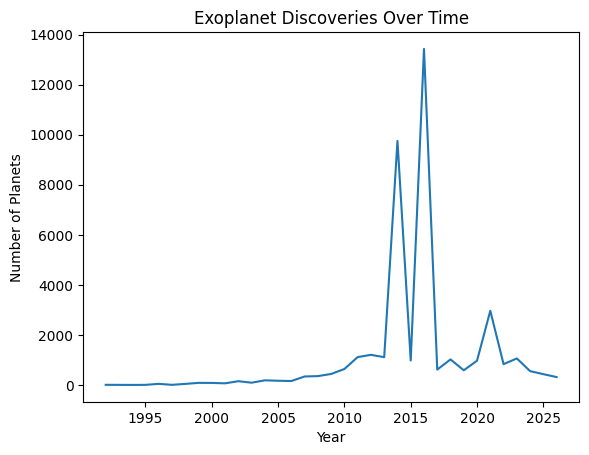

In [41]:
df["disc_year"].value_counts().sort_index().plot()
plt.title("Exoplanet Discoveries Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Planets")
plt.show()

In [43]:
search = lk.search_lightcurve("XO-2", mission = "TESS")
print(search)
lc = search[0].download()

SearchResult containing 12 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 20 2019      SPOC     120   356473034      0.0
  1 TESS Sector 47 2021      SPOC     120   356473034      0.0
  2 TESS Sector 60 2022      SPOC      20   356473034      0.0
  3 TESS Sector 60 2022      SPOC     120   356473034      0.0
  4 TESS Sector 20 2019 TESS-SPOC    1800   356473034      0.0
  5 TESS Sector 47 2021 TESS-SPOC     600   356473034      0.0
  6 TESS Sector 60 2022 TESS-SPOC     200   356473034      0.0
  7 TESS Sector 20 2019       QLP    1800   356473034      0.0
  8 TESS Sector 47 2021       QLP     600   356473034      0.0
  9 TESS Sector 60 2022       QLP     200   356473034      0.0
 10 TESS Sector 20 2019     CDIPS    1800   356473034      0.0
 11 TESS Sector 47 2021     CDIPS    1800   356473034      0.0


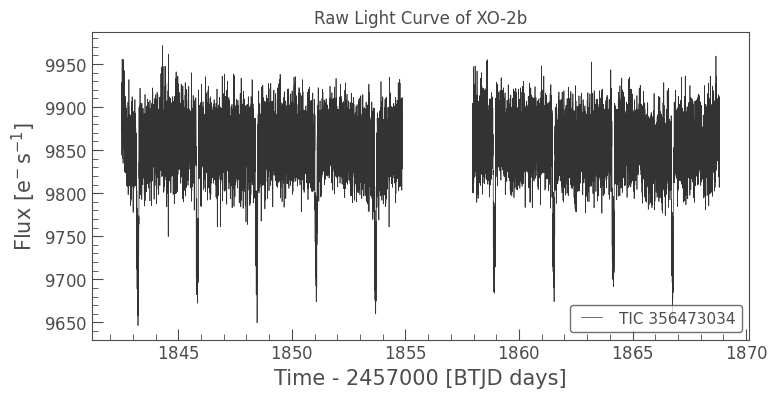

In [87]:
lc.plot()
plt.title("Raw Light Curve of XO-2b")
plt.show()

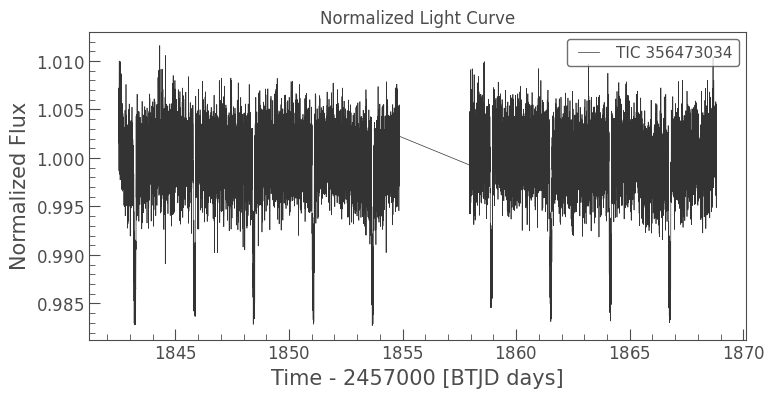

In [82]:
lc_clean = lc.remove_nans().remove_outliers()
lc_norm = lc_clean.normalize()
lc_norm.plot()
plt.title("Normalized Light Curve")
plt.show()

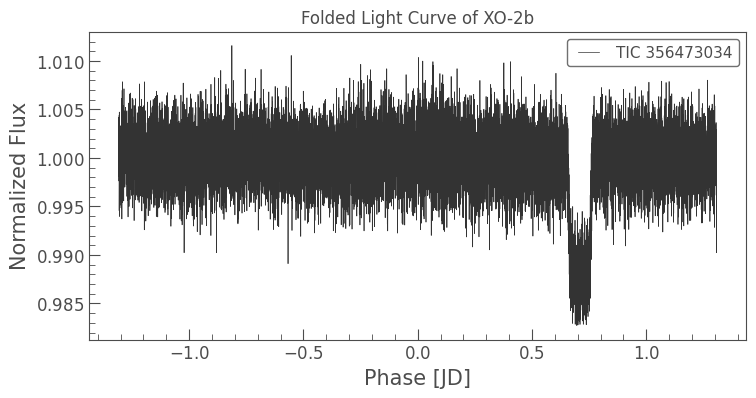

In [83]:
lc_folded = lc_norm.fold(period = 2.6159)
lc_folded.plot()
plt.title("Folded Light Curve of XO-2b")
plt.show()

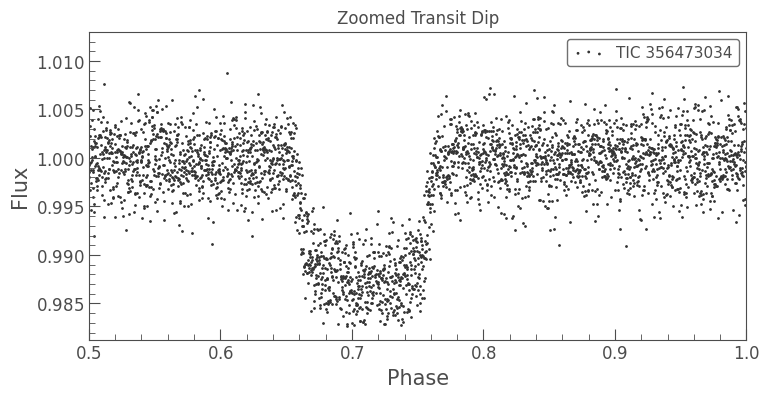

In [84]:
lc_folded.scatter()
plt.xlim(0.5, 1)
plt.xlabel("Phase")
plt.ylabel("Flux")
plt.title("Zoomed Transit Dip")
plt.show()

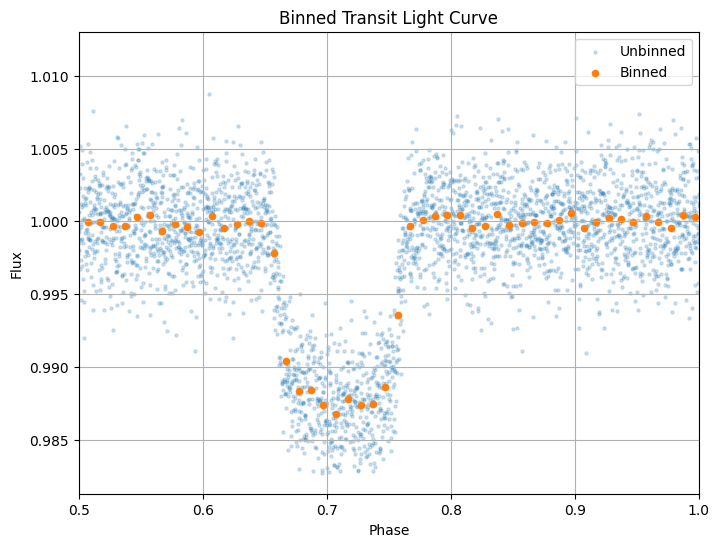

In [93]:
lc_binned = lc_folded.bin(time_bin_size = 0.01)
plt.figure(figsize = (8,6))
plt.scatter(lc_folded.phase.value, lc_folded.flux.value, s = 5, alpha = 0.2, label = "Unbinned")
plt.scatter(lc_binned.phase.value, lc_binned.flux.value, s = 20, label = "Binned")
plt.xlim(0.5, 1)
plt.xlabel("Phase")
plt.ylabel("Flux")
plt.title("Binned Transit Light Curve")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
min_flux = np.nanmin(lc_binned.flux.value)
depth = 1 - min_flux

print("Estimated transit depth:", depth)
print("Percent drop in brightness:", depth * 100, "%")

Estimated transit depth: 0.013223946
Percent drop in brightness: 1.3223946 %
